# Лабораторная 4

  

1. Сгенерировать набор данных при помощи make_classification из sklearn.

2. Построить нейронную сеть для решения задачи классификации (можете использовать лабораторную 3).

3. Исследовать влияние различных классификаторов на качество модели (SGD, Adam, RMSProp), записать выводы.

4. Добавить к модели метод регуляризации Dropout и повторить пункт 3 уже с ним.

  

*Дополнительное задание:

Повторить пункты 2-4 для набора данных MNIST.*

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

In [53]:
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=15,
    n_redundant=2,
    n_repeated=1,
    n_classes=3,
    n_clusters_per_class=2,
    weights=[0.2, 0.3, 0.5],
    flip_y=0.05,
    random_state=42
)

print(f"Распределение классов: {np.bincount(y)}")

Распределение классов: [2042 3033 4925]


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train_categorical = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_test_categorical = tf.keras.utils.to_categorical(y_test, num_classes=3)

### Без дропаута

In [55]:
def buildmodel(optimizer='adam', learning_rate=0.001):
    model = models.Sequential([
        layers.Input(shape=(20,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])
    
    if optimizer.lower() == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer.lower() == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


def traineval(model, X_train, y_train, X_test, y_test, 
                      optimizer_name, epochs=50, batch_size=32):

    print(f"\nОбучение модели с оптимизатором {optimizer_name}")

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)
    
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    
    report = classification_report(y_true_classes, y_pred_classes, output_dict=True)
    
    results = {
        'optimizer': optimizer_name,
        'test_accuracy': test_accuracy,
        'test_loss': test_loss,
        'history': history.history,
        'confusion_matrix': cm,
        'classification_report': report,
        'model': model
    }
    
    print(f" -=- Точность на тесте: {test_accuracy:.4f}")
    print(f" -=- Потери на тесте: {test_loss:.4f}")
    print(f" -=- Матрица ошибок: \n{cm}")
    print()
    
    return results

In [56]:
optimizers = ['SGD', 'Adam', 'RMSProp']
results = []

for opt in optimizers:
    model = buildmodel(optimizer=opt)
    res = traineval(model, 
                    X_train, y_train_categorical, 
                    X_test, y_test_categorical, 
                    opt)
    results.append(res)


Обучение модели с оптимизатором SGD
 -=- Точность на тесте: 0.8410
 -=- Потери на тесте: 0.4650
 -=- Матрица ошибок: 
[[264  65  79]
 [ 43 524  40]
 [ 49  42 894]]


Обучение модели с оптимизатором Adam
 -=- Точность на тесте: 0.8925
 -=- Потери на тесте: 0.5655
 -=- Матрица ошибок: 
[[332  30  46]
 [ 39 535  33]
 [ 43  24 918]]


Обучение модели с оптимизатором RMSProp
 -=- Точность на тесте: 0.9000
 -=- Потери на тесте: 0.5138
 -=- Матрица ошибок: 
[[333  41  34]
 [ 37 543  27]
 [ 36  25 924]]



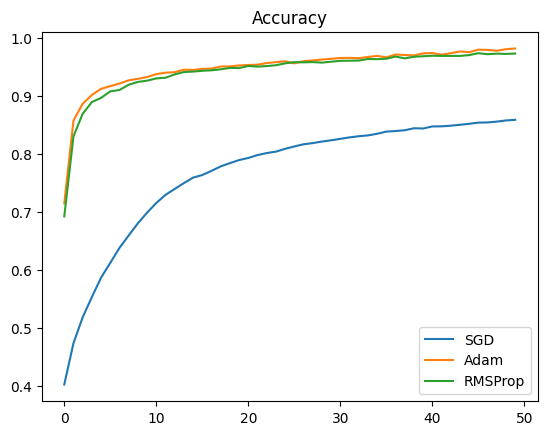

In [57]:
plt.title("Accuracy")
for res in results:
    plt.plot(res["history"]["accuracy"], label=res["optimizer"])
    plt.legend()

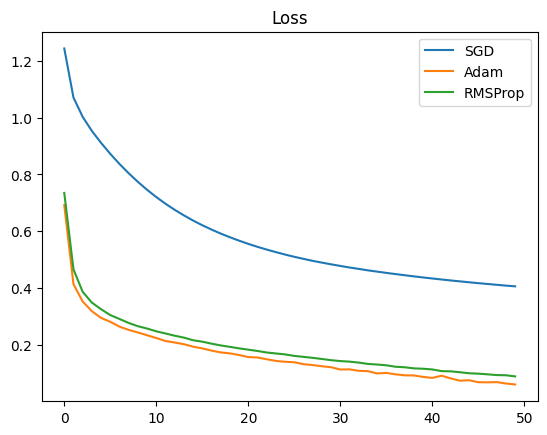

In [58]:
plt.title("Loss")
for res in results:
    plt.plot(res["history"]["loss"], label=res["optimizer"])
    plt.legend()

### С дропаутом

In [59]:
def buildmodel(optimizer='adam', learning_rate=0.001):
    dropout_rate = 0.3
    
    model = models.Sequential([
        layers.Input(shape=(20,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(16, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(3, activation='softmax')
    ])
    
    if optimizer.lower() == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer.lower() == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [60]:
optimizers = ['SGD', 'Adam', 'RMSProp']
results = []

for opt in optimizers:
    model = buildmodel(optimizer=opt)
    res = traineval(model, 
                    X_train, y_train_categorical, 
                    X_test, y_test_categorical, 
                    opt)
    results.append(res)


Обучение модели с оптимизатором SGD
 -=- Точность на тесте: 0.7260
 -=- Потери на тесте: 0.6946
 -=- Матрица ошибок: 
[[ 34 120 254]
 [  2 476 129]
 [  1  42 942]]


Обучение модели с оптимизатором Adam
 -=- Точность на тесте: 0.9300
 -=- Потери на тесте: 0.2754
 -=- Матрица ошибок: 
[[340  33  35]
 [ 25 560  22]
 [ 14  11 960]]


Обучение модели с оптимизатором RMSProp
 -=- Точность на тесте: 0.9210
 -=- Потери на тесте: 0.3150
 -=- Матрица ошибок: 
[[333  37  38]
 [ 20 560  27]
 [ 22  14 949]]



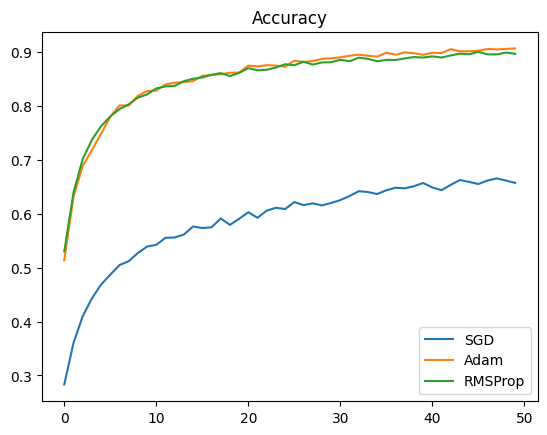

In [ ]:
plt.title("Accuracy")
for res in results:
    plt.plot(res["history"]["accuracy"], label=res["optimizer"])
    plt.legend()

Адам дал ожидаемо лучший результат в обоих обучениях

## MNIST

In [66]:
from tensorflow.keras.datasets import mnist

(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

In [77]:
def buildmodel(optimizer='adam', learning_rate=0.001, use_dropout=False):
    model = models.Sequential()
    dropout_rate = 0.3
    
    # Сверточные блоки
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                           input_shape=(28, 28, 1)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    
    # Полносвязные слои
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Dense(64, activation='relu'))
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Dense(10, activation='softmax'))
    
    if optimizer.lower() == 'sgd':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)
    elif optimizer.lower() == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


def traineval(model, X_train, y_train, X_val, y_val, X_test, y_test,
              optimizer_name,  epochs=20, batch_size=64):

    print(f"\nОбучение модели с оптимизатором {optimizer_name}")

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )
    
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred_proba, axis=1)
    
    cm = confusion_matrix(y_test, y_pred_classes)
    
    report = classification_report(y_test, y_pred_classes, output_dict=True)
    
    results = {
        'optimizer': optimizer_name,
        'test_accuracy': test_accuracy,
        'test_loss': test_loss,
        'history': history.history,
        'confusion_matrix': cm,
        'classification_report': report,
        'model': model,
        'predictions': y_pred_proba,
        'y_true': y_test,
        'y_pred': y_pred_classes
    }
    
    print(f" -=- Точность на валидации: {max(history.history['val_accuracy']):.4f}")
    print(f" -=- Точность на тесте: {test_accuracy:.4f}")
    print(f" -=- Потери на тесте: {test_loss:.4f}")
    
    return results

In [80]:
optimizers = ['SGD', 'Adam', 'RMSProp']
results = []

for opt in optimizers:
    model = buildmodel(optimizer=opt, learning_rate=0.001, use_dropout=False)
    res = traineval(
        model, X_train, y_train, X_val, y_val, X_test, y_test,
        opt, epochs=5
    )
    results.append(res)


Обучение модели с оптимизатором SGD
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.9466 - loss: 0.1812 - val_accuracy: 0.9752 - val_loss: 0.0837
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.9852 - loss: 0.0488 - val_accuracy: 0.9840 - val_loss: 0.0521
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.9915 - loss: 0.0304 - val_accuracy: 0.9864 - val_loss: 0.0474
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.9944 - loss: 0.0203 - val_accuracy: 0.9877 - val_loss: 0.0406
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.9970 - loss: 0.0139 - val_accuracy: 0.9872 - val_loss: 0.0417
 -=- Точность на валидации: 0.9877
 -=- Точность на тесте: 0.9876
 -=- Потери на тесте: 0.0373

Обучение модели с оптимизатором Adam
Epoch 1/5


c:\Users\Lenovo\Desktop\CodeShit\Jupyter\neurona4ki_4curse\hui\hui\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.9618 - loss: 0.1269 - val_accuracy: 0.9775 - val_loss: 0.0731
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9870 - loss: 0.0426 - val_accuracy: 0.9819 - val_loss: 0.0616
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9902 - loss: 0.0315 - val_accuracy: 0.9845 - val_loss: 0.0532
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9926 - loss: 0.0233 - val_accuracy: 0.9841 - val_loss: 0.0596
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9931 - loss: 0.0220 - val_accuracy: 0.9857 - val_loss: 0.0555
 -=- Точность на валидации: 0.9857
 -=- Точность на тесте: 0.9871
 -=- Потери на тесте: 0.0386

Обучение модели с оптимизатором RMSProp
Epoch 1/5


c:\Users\Lenovo\Desktop\CodeShit\Jupyter\neurona4ki_4curse\hui\hui\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.9552 - loss: 0.1530 - val_accuracy: 0.9729 - val_loss: 0.0955
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.9858 - loss: 0.0504 - val_accuracy: 0.9857 - val_loss: 0.0629
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9905 - loss: 0.0352 - val_accuracy: 0.9884 - val_loss: 0.0531
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.9925 - loss: 0.0264 - val_accuracy: 0.9636 - val_loss: 0.1618
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9938 - loss: 0.0218 - val_accuracy: 0.9841 - val_loss: 0.0847
 -=- Точность на валидации: 0.9884
 -=- Точность на тесте: 0.9841
 -=- Потери на тесте: 0.0850


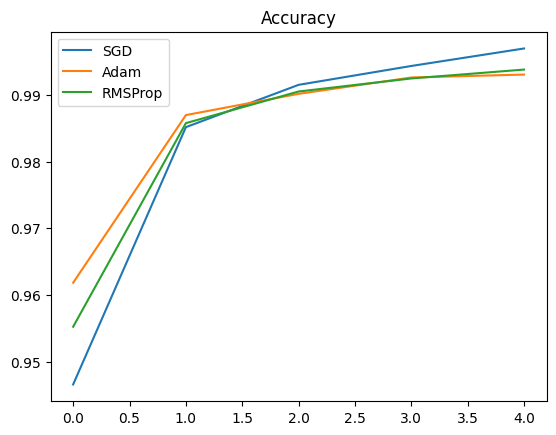

In [81]:
plt.title("Accuracy")
for res in results:
    plt.plot(res["history"]["accuracy"], label=res["optimizer"])
    plt.legend()

In [82]:
optimizers = ['SGD', 'Adam', 'RMSProp']
results = []

for opt in optimizers:
    model = buildmodel(optimizer=opt, learning_rate=0.001, use_dropout=True)
    res = traineval(
        model, X_train, y_train, X_val, y_val, X_test, y_test,
        opt, epochs=5
    )
    results.append(res)


Обучение модели с оптимизатором SGD
Epoch 1/5


c:\Users\Lenovo\Desktop\CodeShit\Jupyter\neurona4ki_4curse\hui\hui\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.6643 - loss: 1.0138 - val_accuracy: 0.9439 - val_loss: 0.1951
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.8951 - loss: 0.3463 - val_accuracy: 0.9721 - val_loss: 0.1009
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.9284 - loss: 0.2463 - val_accuracy: 0.9764 - val_loss: 0.0806
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9433 - loss: 0.1992 - val_accuracy: 0.9796 - val_loss: 0.0712
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9512 - loss: 0.1750 - val_accuracy: 0.9812 - val_loss: 0.0695
 -=- Точность на валидации: 0.9812
 -=- Точность на тесте: 0.9822
 -=- Потери на тесте: 0.0555

Обучение модели с оптимизатором Adam
Epoch 1/5


c:\Users\Lenovo\Desktop\CodeShit\Jupyter\neurona4ki_4curse\hui\hui\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.8378 - loss: 0.5144 - val_accuracy: 0.9767 - val_loss: 0.0822
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9601 - loss: 0.1450 - val_accuracy: 0.9842 - val_loss: 0.0614
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9716 - loss: 0.1051 - val_accuracy: 0.9890 - val_loss: 0.0414
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9758 - loss: 0.0874 - val_accuracy: 0.9868 - val_loss: 0.0465
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9792 - loss: 0.0766 - val_accuracy: 0.9900 - val_loss: 0.0391
 -=- Точность на валидации: 0.9900
 -=- Точность на тесте: 0.9916
 -=- Потери на тесте: 0.0294

Обучение модели с оптимизатором RMSProp
Epoch 1/5


c:\Users\Lenovo\Desktop\CodeShit\Jupyter\neurona4ki_4curse\hui\hui\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.8587 - loss: 0.4643 - val_accuracy: 0.9739 - val_loss: 0.1019
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9627 - loss: 0.1491 - val_accuracy: 0.9820 - val_loss: 0.0808
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9704 - loss: 0.1257 - val_accuracy: 0.9862 - val_loss: 0.0592
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9737 - loss: 0.1117 - val_accuracy: 0.9887 - val_loss: 0.0445
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9753 - loss: 0.1043 - val_accuracy: 0.9880 - val_loss: 0.0511
 -=- Точность на валидации: 0.9887
 -=- Точность на тесте: 0.9897
 -=- Потери на тесте: 0.0388


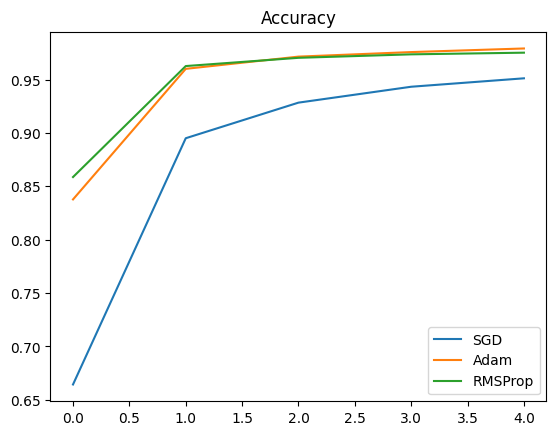

In [83]:
plt.title("Accuracy")
for res in results:
    plt.plot(res["history"]["accuracy"], label=res["optimizer"])
    plt.legend()

Видимо в силу малого числа эпох адам сначала дал неожиданно худший результат (хотя там разницей можно принебречь), на дропауте же наоборот он вырвался вперед, что говорит об его устойчивости